In [12]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [14]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# Load Final Preprocessed Dataset
# ============================================================

path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Final_Preprocessed.xlsx"

df = pd.read_excel(path)

print(df.shape)
df.head()

(1539, 15)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Hospital
0,32.0,Male,94.6,5.4,0.0,0.0,0.0,6.79,13.3,47.3,69.7,19.7,28.2,Beta Thalassemia Minor,KTH
1,21.0,Female,98.0,2.0,0.0,0.0,0.0,3.88,8.6,29.5,76.0,24.0,31.0,Normal,KTH
2,30.0,Female,97.0,2.1,0.0,0.0,0.0,3.96,7.9,27.8,70.1,19.9,28.4,Normal,KTH
3,2.0,Female,94.3,5.7,0.0,0.0,0.0,6.26,11.8,36.2,57.8,18.8,32.5,Beta Thalassemia Minor,KTH
4,37.0,Female,94.7,5.4,0.0,0.0,0.0,4.42,8.2,27.1,61.4,18.5,30.1,Beta Thalassemia Minor,KTH


In [15]:
# Convert categorical columns
categorical_cols = ["Gender", "Hospital", "Results"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df.dtypes)

Age          float64
Gender      category
Hb-A         float64
HB-A2        float64
Hb-F         float64
Hb-S         float64
Hb-D         float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
Results     category
Hospital    category
dtype: object


In [16]:
print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

print("\nTarget Classes")
print(df["Results"].value_counts())

DATASET LOADED SUCCESSFULLY
Shape: (1539, 15)
Missing Values: 0
Duplicate Records: 2

Data Types
Age          float64
Gender      category
Hb-A         float64
HB-A2        float64
Hb-F         float64
Hb-S         float64
Hb-D         float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
Results     category
Hospital    category
dtype: object

Target Classes
Results
Normal                    1118
Beta Thalassemia Minor     350
Beta Thalassemia Major      22
Borderline HbA2             22
Sickle Disorders            17
Hb D Trait                  10
Name: count, dtype: int64


In [17]:
# ============================================================
# Final Dataset Summary
# ============================================================

print("="*70)
print("FINAL PREPROCESSED DATASET")
print("="*70)

print(f"Dataset Shape      : {df.shape}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Records  : {df.duplicated().sum()}")

print("\nData Types")
print(df.dtypes)

print("\nDiagnosis Distribution")
print(df["Results"].value_counts())

print("\nGender Distribution")
print(df["Gender"].value_counts())

print("\nHospital Distribution")
print(df["Hospital"].value_counts())

FINAL PREPROCESSED DATASET
Dataset Shape      : (1539, 15)
Missing Values     : 0
Duplicate Records  : 2

Data Types
Age          float64
Gender      category
Hb-A         float64
HB-A2        float64
Hb-F         float64
Hb-S         float64
Hb-D         float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
Results     category
Hospital    category
dtype: object

Diagnosis Distribution
Results
Normal                    1118
Beta Thalassemia Minor     350
Beta Thalassemia Major      22
Borderline HbA2             22
Sickle Disorders            17
Hb D Trait                  10
Name: count, dtype: int64

Gender Distribution
Gender
Female    937
Male      602
Name: count, dtype: int64

Hospital Distribution
Hospital
KTH       1188
Mardan     351
Name: count, dtype: int64


In [18]:
df.head()

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Hospital
0,32.0,Male,94.6,5.4,0.0,0.0,0.0,6.79,13.3,47.3,69.7,19.7,28.2,Beta Thalassemia Minor,KTH
1,21.0,Female,98.0,2.0,0.0,0.0,0.0,3.88,8.6,29.5,76.0,24.0,31.0,Normal,KTH
2,30.0,Female,97.0,2.1,0.0,0.0,0.0,3.96,7.9,27.8,70.1,19.9,28.4,Normal,KTH
3,2.0,Female,94.3,5.7,0.0,0.0,0.0,6.26,11.8,36.2,57.8,18.8,32.5,Beta Thalassemia Minor,KTH
4,37.0,Female,94.7,5.4,0.0,0.0,0.0,4.42,8.2,27.1,61.4,18.5,30.1,Beta Thalassemia Minor,KTH


In [19]:
# ============================================================
# Target Class Distribution
# ============================================================

class_counts = df["Results"].value_counts().sort_values(ascending=False)

class_percent = round(
    class_counts / len(df) * 100,
    2
)

distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent
})

distribution

,Count,Percentage (%)
Results,,
Normal,1118,72.64
Beta Thalassemia Minor,350,22.74
Beta Thalassemia Major,22,1.43
Borderline HbA2,22,1.43
Sickle Disorders,17,1.10
Hb D Trait,10,0.65


In [21]:
# ============================================================
# Descriptive Statistics
# ============================================================

print("="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)

df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Age,1539.0,19.601839,13.704104,0.0,6.00,20.00,28.00,80.0
Hb-A,1539.0,93.982658,13.645376,0.0,95.30,97.30,97.90,99.0
HB-A2,1539.0,2.914451,1.228348,0.0,2.00,2.40,3.30,9.4
Hb-F,1539.0,2.092398,10.717855,0.0,0.00,0.00,0.80,94.3
Hb-S,1539.0,0.386485,4.295156,0.0,0.00,0.00,0.00,67.0
Hb-D,1539.0,0.289344,3.340330,0.0,0.00,0.00,0.00,63.2
RBC,1539.0,4.840715,12.646505,0.0,3.95,4.54,5.15,499.0
HGB,1539.0,9.964107,4.601356,1.6,7.90,9.40,11.70,113.0
HCT,1539.0,33.390273,8.836416,5.8,27.95,32.30,38.40,86.1
MCV,1539.0,73.852567,13.785489,17.9,63.65,72.30,84.85,128.3


In [22]:
# ============================================================
# Descriptive Statistics by Diagnosis
# ============================================================

df.groupby("Results", observed=True).mean(numeric_only=True)

,Age,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC
Results,,,,,,,,,,,,
Beta Thalassemia Major,1.749091,15.754545,1.390909,74.054545,0.000000,0.000000,2.690909,5.705000,18.618182,68.354545,21.590909,30.713636
Beta Thalassemia Minor,22.482171,93.001143,4.850857,1.806571,0.070000,0.009714,6.651400,10.286000,33.817429,64.303714,18.830571,29.175371
Borderline HbA2,18.636364,95.418182,3.095455,1.395455,0.000000,0.000000,3.934091,7.981364,27.290909,69.995455,21.527273,29.913636
Hb D Trait,22.800000,67.060000,2.940000,0.080000,0.000000,33.120000,4.602000,10.900000,35.390000,76.980000,23.290000,30.430000
Normal,19.075125,96.921565,2.318909,0.550984,0.000000,0.000000,4.346369,9.982504,33.698864,76.960197,23.130769,30.188148
Sickle Disorders,17.411765,36.129412,3.935294,18.305882,33.547059,6.511765,4.168235,9.654118,30.135294,76.341176,27.135294,30.735294


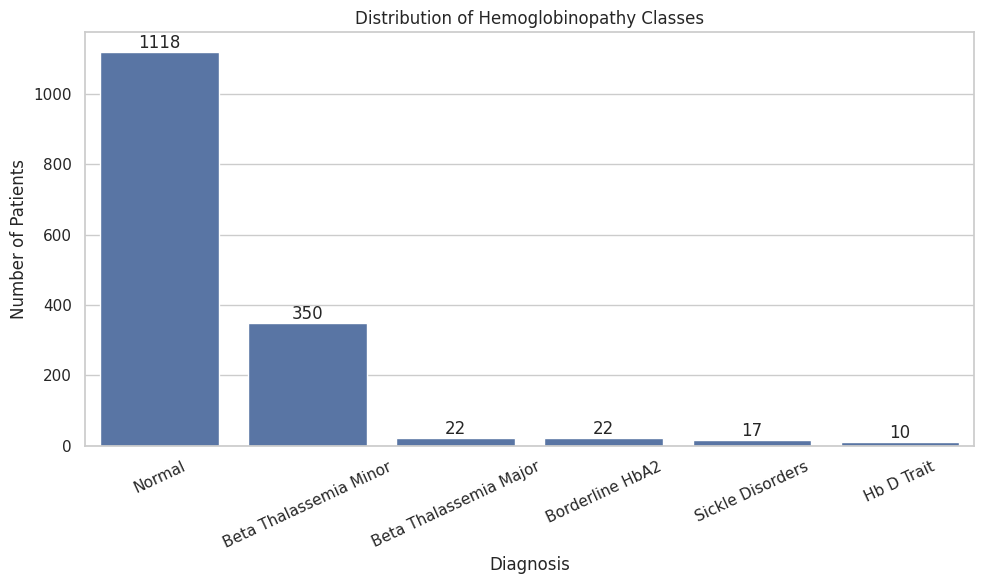

In [27]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Results",
    order=df["Results"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=25)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.title("Distribution of Hemoglobinopathy Classes")

plt.tight_layout()
plt.show()

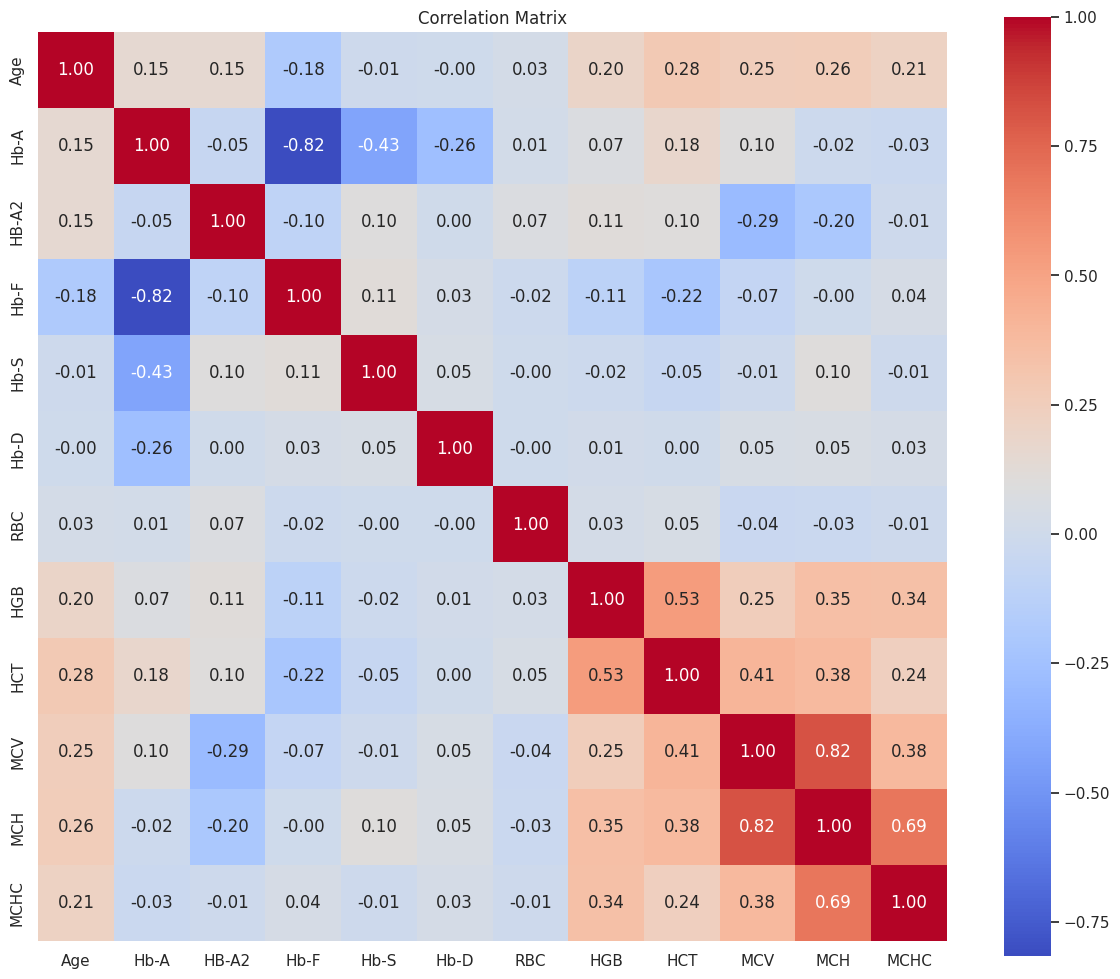

In [25]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,10))

corr = df[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

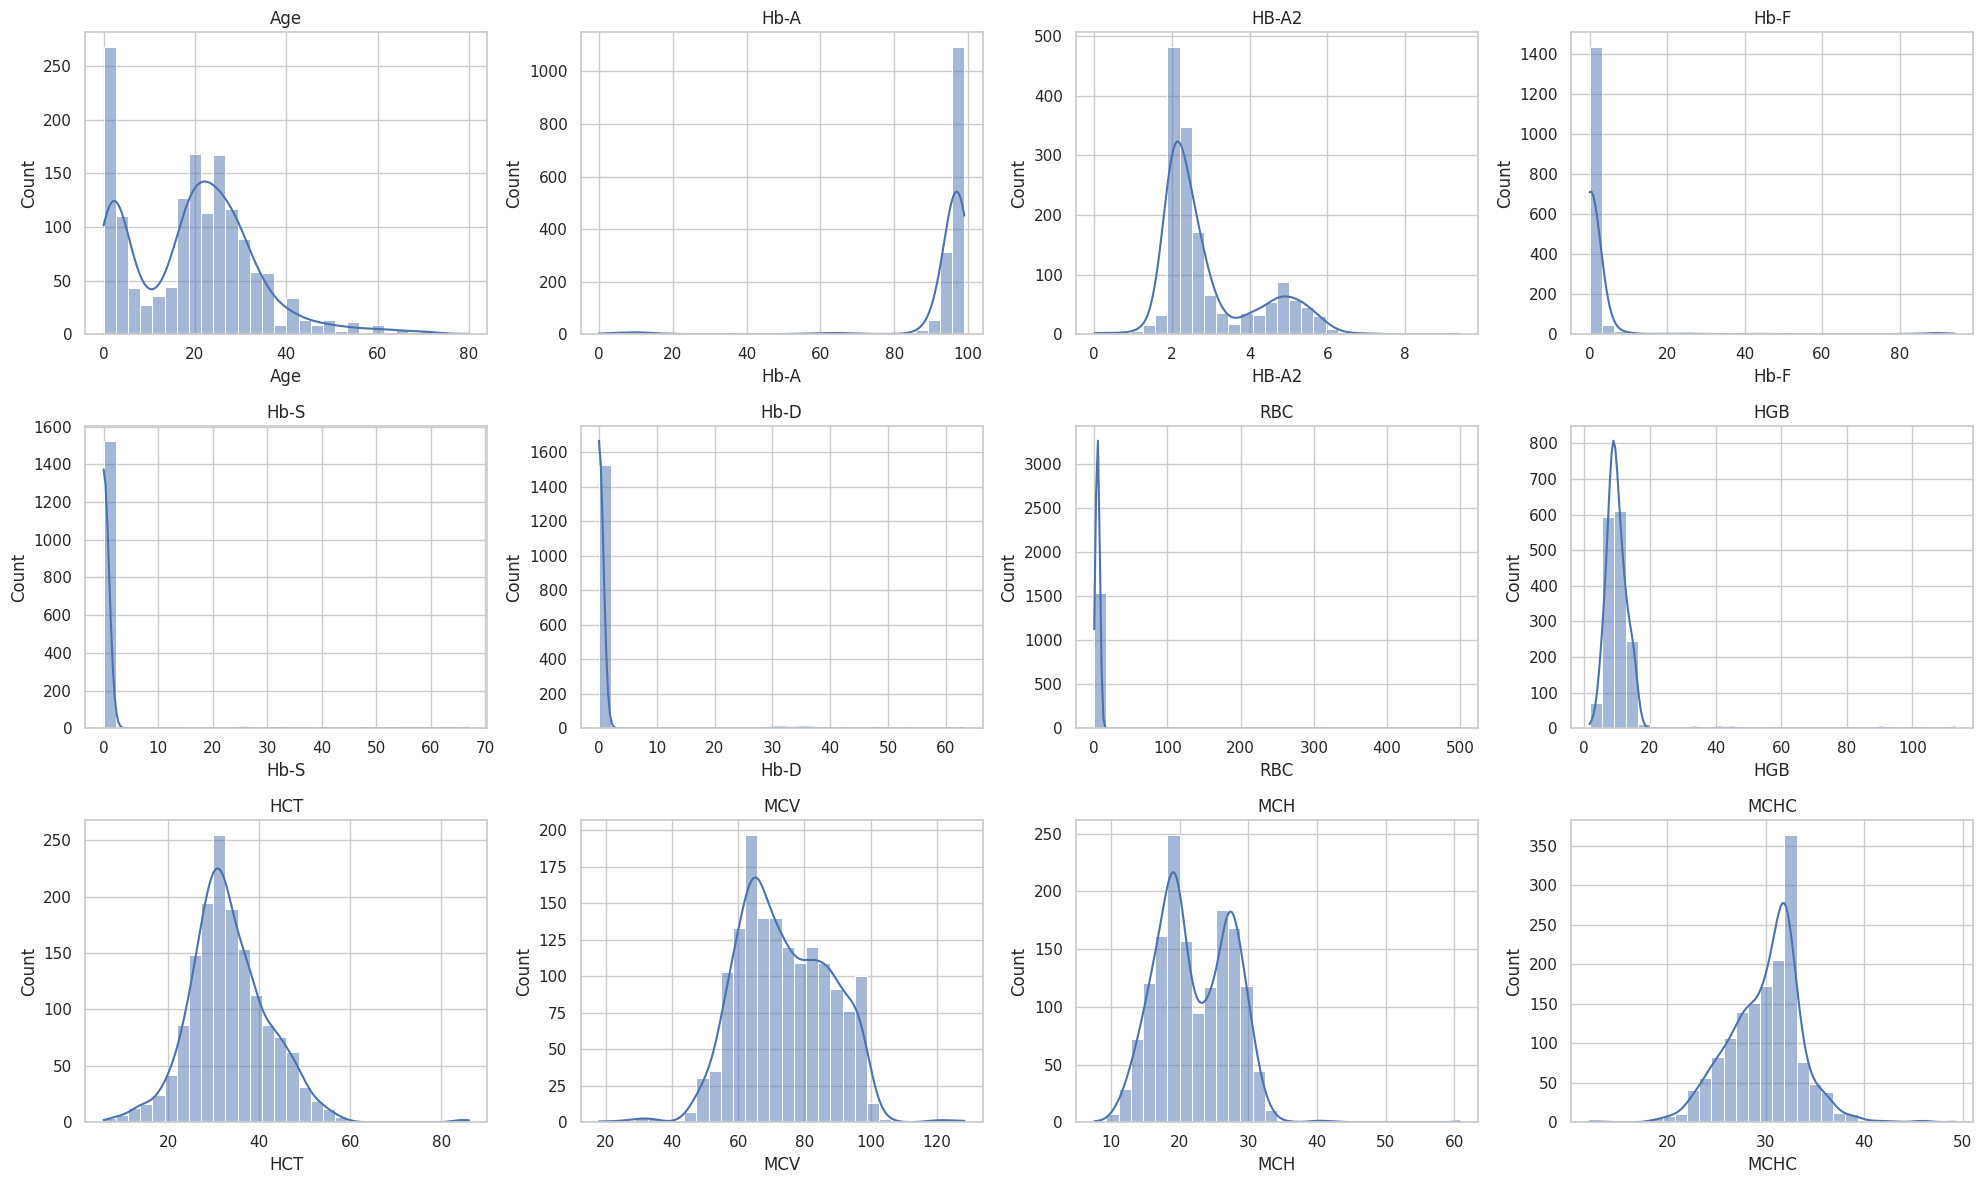

In [30]:
# ============================================================
# Distribution of Numerical Features
# ============================================================

numerical_features = [
    "Age","Hb-A","HB-A2","Hb-F","Hb-S","Hb-D",
    "RBC","HGB","HCT","MCV","MCH","MCHC"
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=30,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

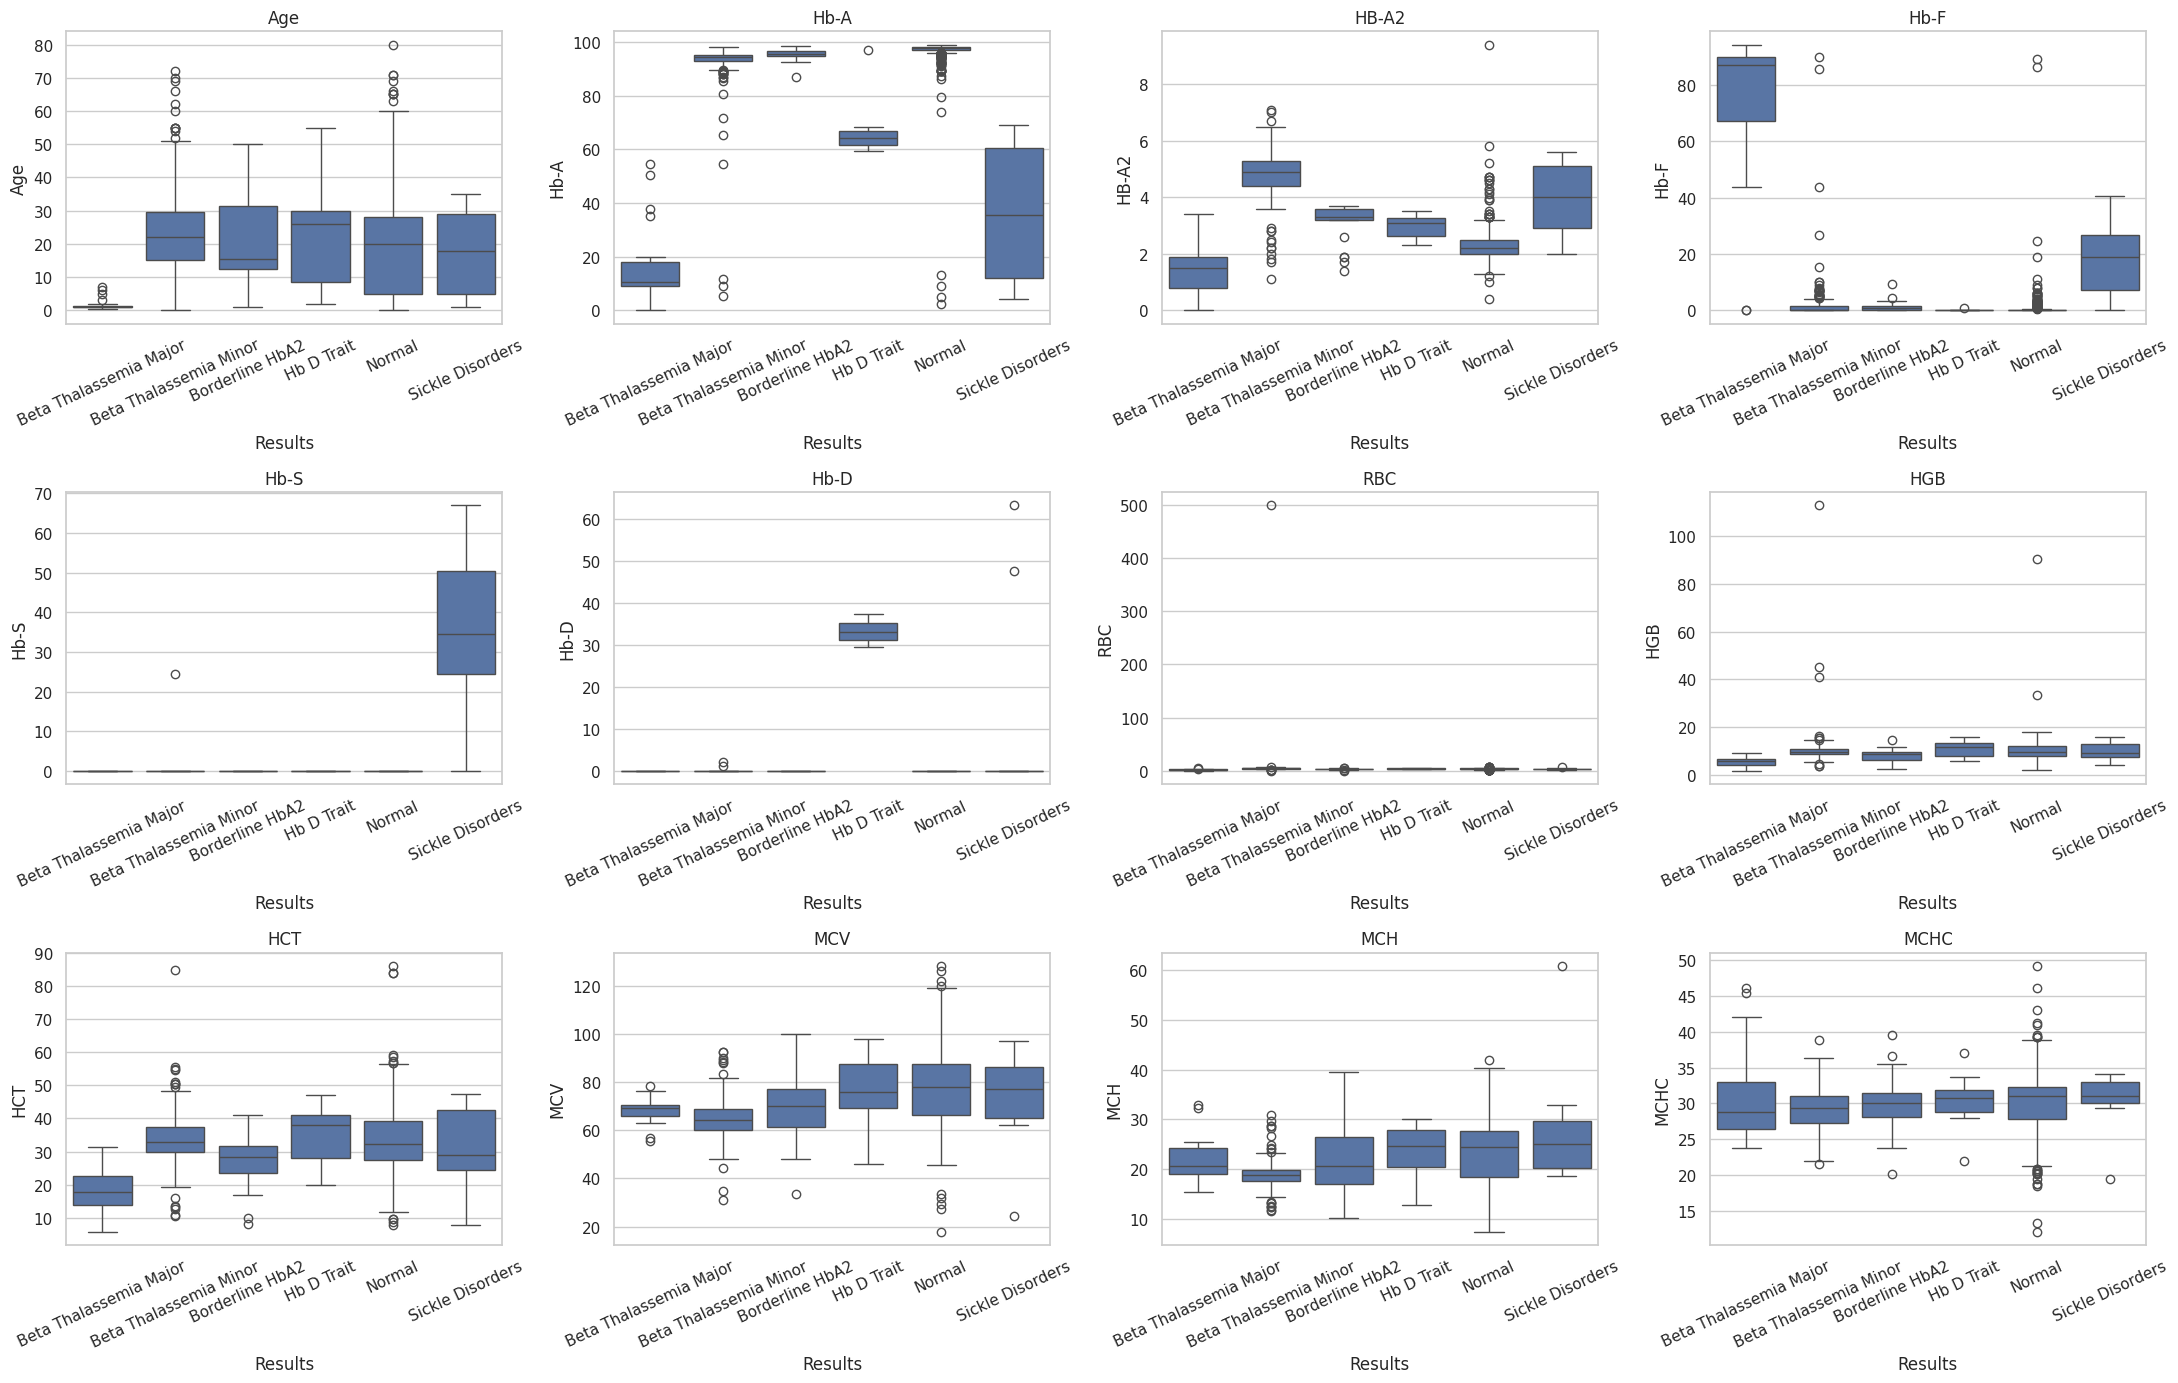

In [31]:
# ============================================================
# Boxplots by Diagnosis
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(22, 14))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x="Results",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

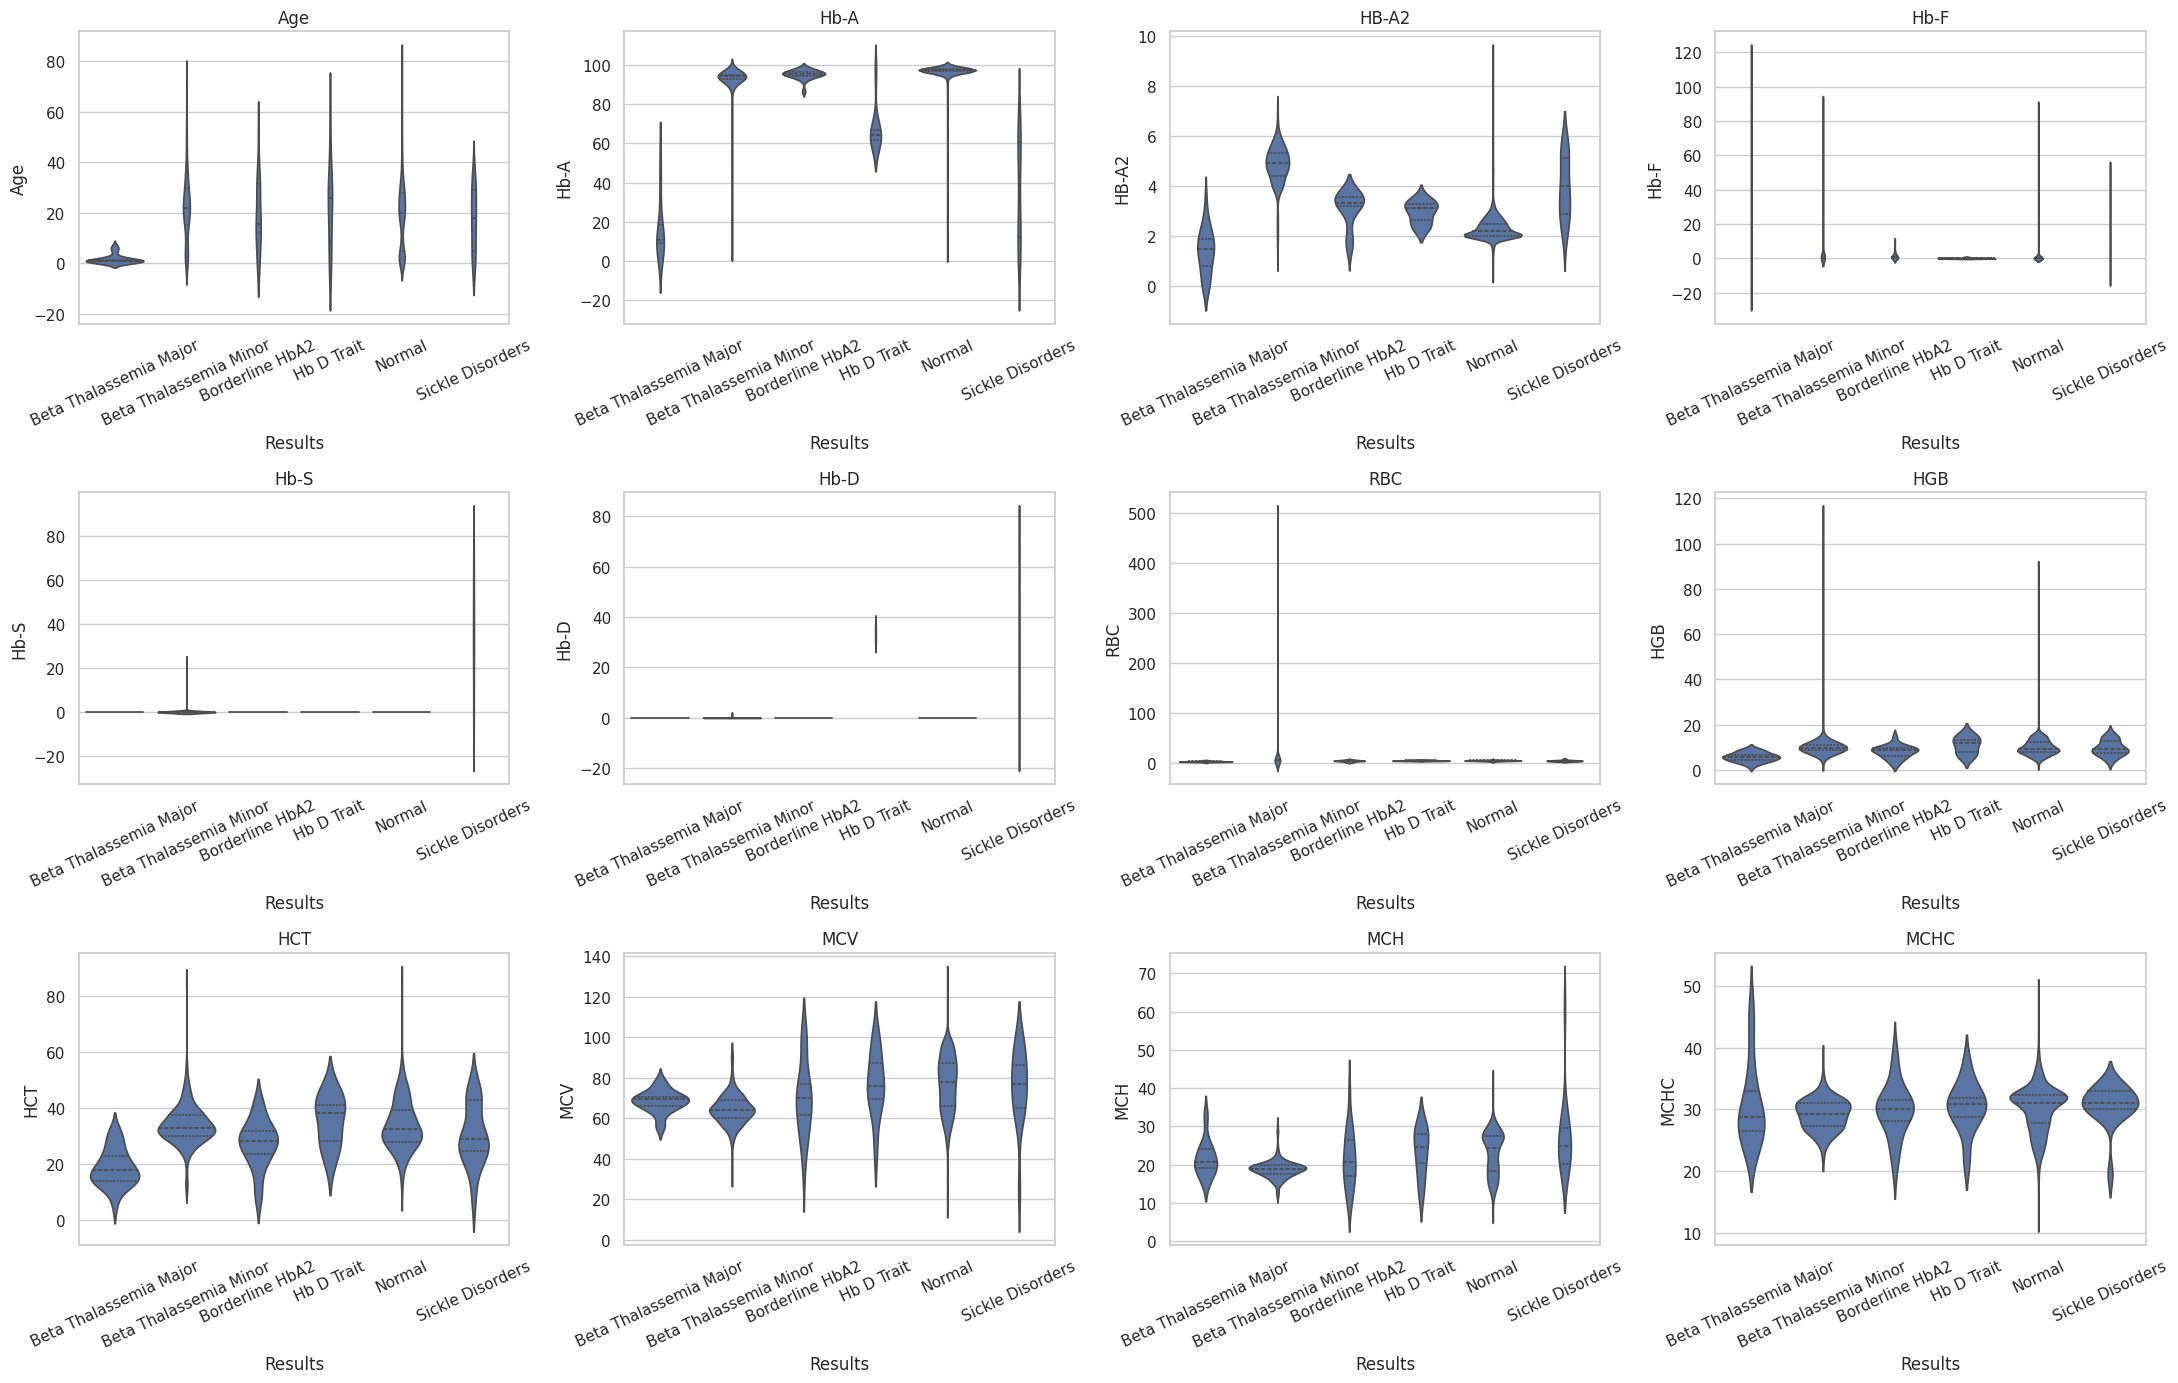

In [32]:
# ============================================================
# Violin Plots by Diagnosis
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(22, 14))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.violinplot(
        data=df,
        x="Results",
        y=feature,
        ax=axes[i],
        inner="quartile"
    )

    axes[i].set_title(feature)
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import kruskal

In [34]:
# ============================================================
# Kruskal-Wallis Test
# ============================================================

numerical_features = [
    "Age","Hb-A","HB-A2","Hb-F","Hb-S","Hb-D",
    "RBC","HGB","HCT","MCV","MCH","MCHC"
]

results = []

for feature in numerical_features:

    groups = [
        group[feature].dropna()
        for _, group in df.groupby("Results", observed=True)
    ]

    stat, p = kruskal(*groups)

    results.append({
        "Feature": feature,
        "H Statistic": round(stat, 3),
        "P-value": p
    })

kruskal_results = pd.DataFrame(results)

kruskal_results["Significant"] = kruskal_results["P-value"] < 0.05

kruskal_results.sort_values("P-value")

,Feature,H Statistic,P-value,Significant
5,Hb-D,1122.248,2.032588e-240,True
4,Hb-S,1089.620,2.365595e-233,True
2,HB-A2,813.386,1.470173e-173,True
1,Hb-A,774.824,3.231957e-165,True
6,RBC,269.887,2.959224e-56,True
9,MCV,260.987,2.411010e-54,True
3,Hb-F,181.750,2.262898e-37,True
10,MCH,178.030,1.409634e-36,True
8,HCT,61.620,5.621102e-12,True
0,Age,60.626,9.024045e-12,True


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
temp = df.copy()

temp["Gender"] = LabelEncoder().fit_transform(temp["Gender"])
temp["Hospital"] = LabelEncoder().fit_transform(temp["Hospital"])
temp["Results"] = LabelEncoder().fit_transform(temp["Results"])

X = temp.drop("Results", axis=1)
y = temp["Results"]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance

,Feature,Importance
3,HB-A2,0.348945
2,Hb-A,0.275939
11,MCH,0.070550
10,MCV,0.055143
7,RBC,0.054996
4,Hb-F,0.044908
8,HGB,0.033195
12,MCHC,0.027799
9,HCT,0.027169
0,Age,0.025375


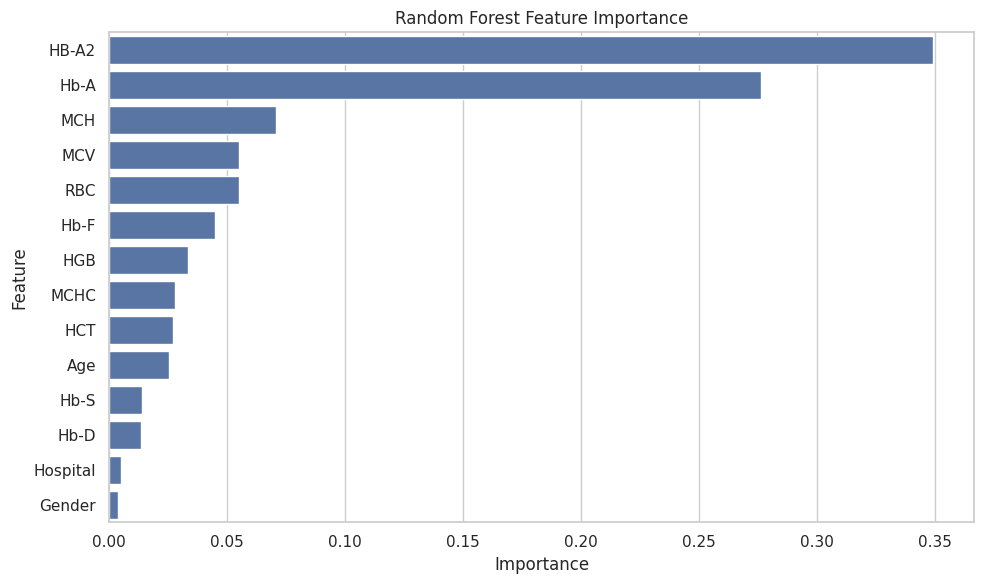

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

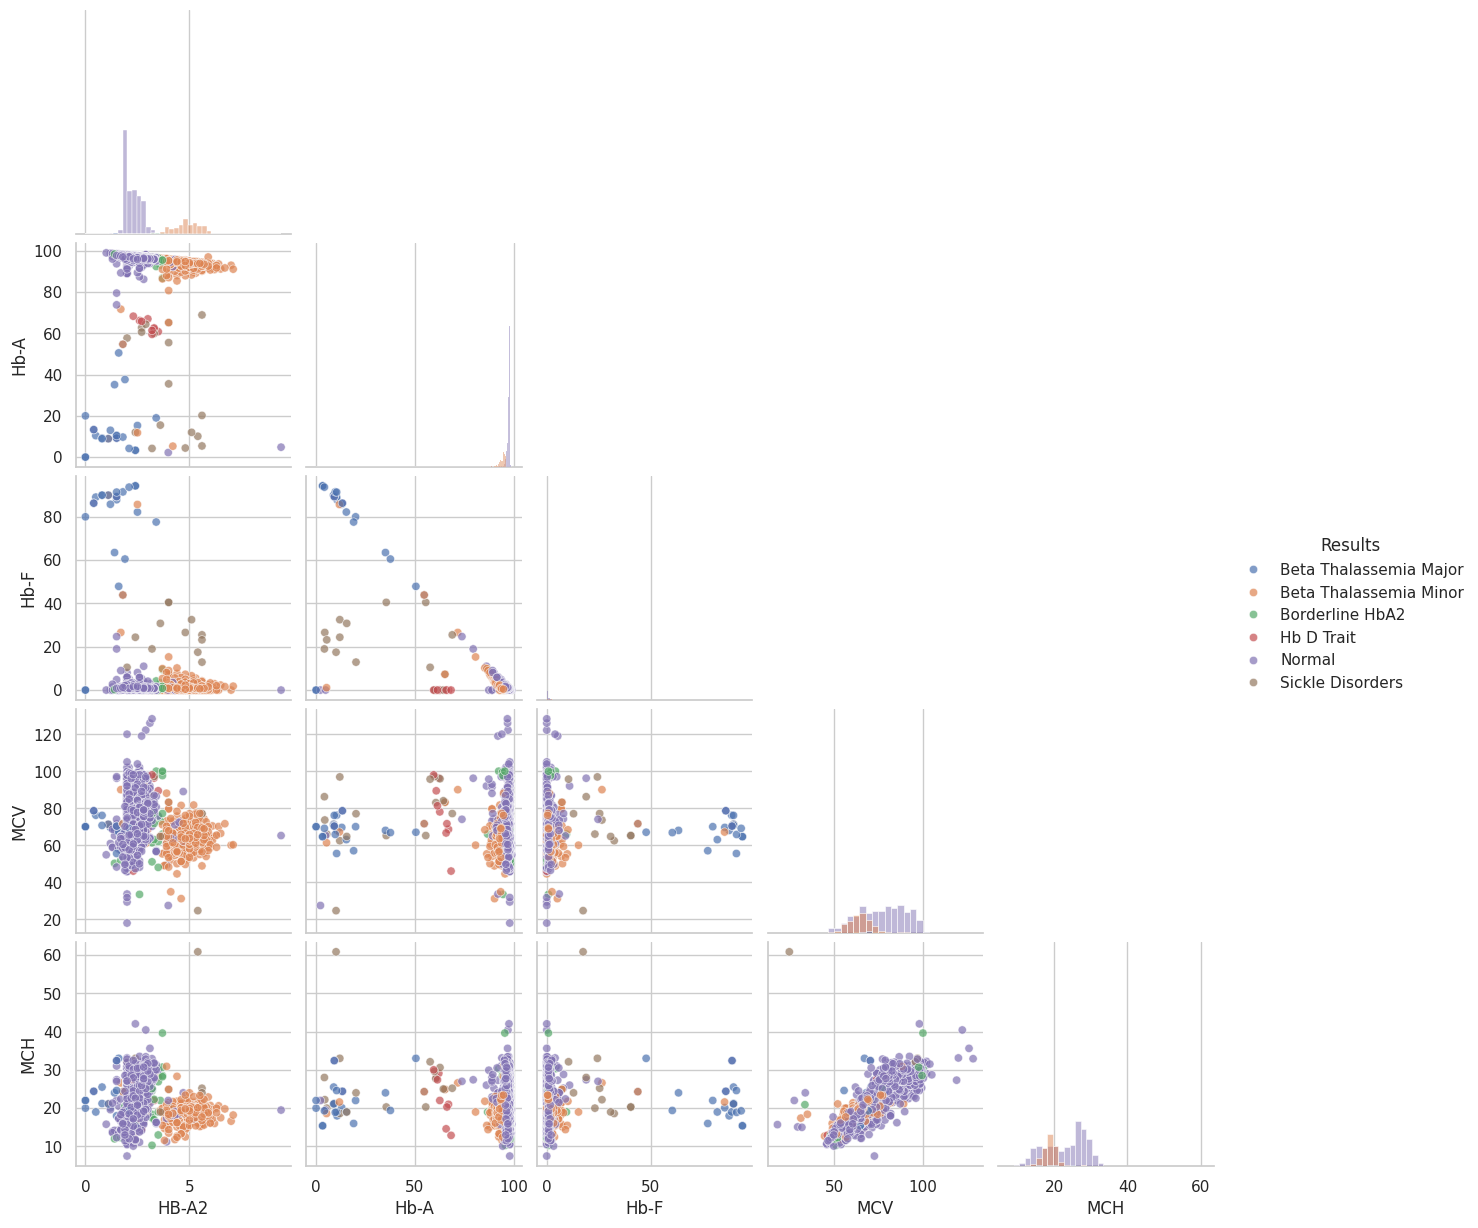

In [37]:
# ============================================================
# Pairwise Relationships of Important Features
# ============================================================

top_features = [
    "HB-A2",
    "Hb-A",
    "Hb-F",
    "MCV",
    "MCH",
    "Results"
]

sns.pairplot(
    df[top_features],
    hue="Results",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.7}
)

plt.show()

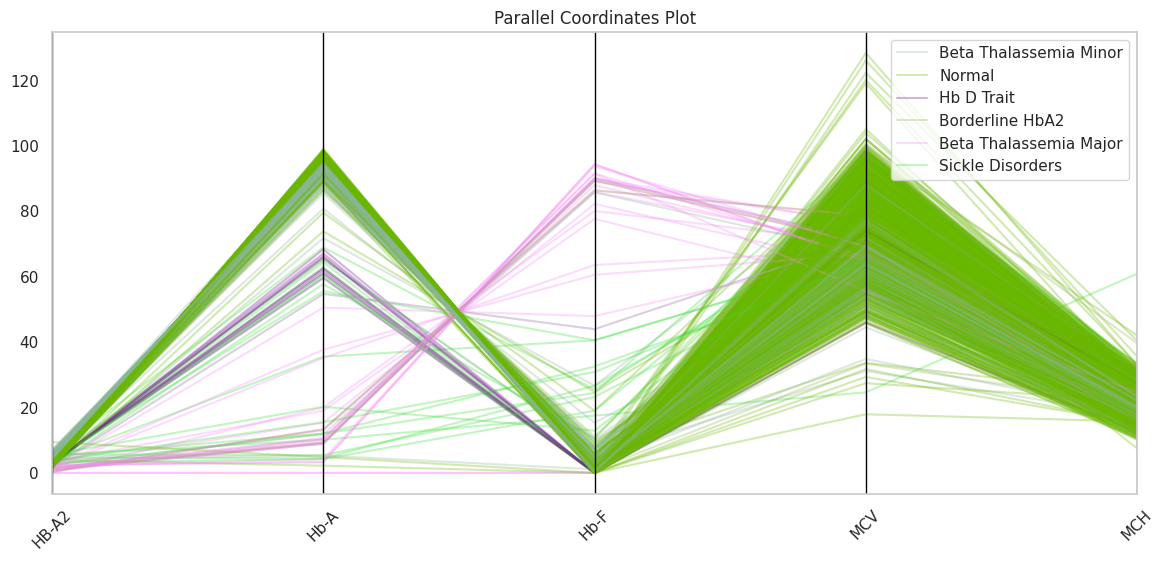

In [42]:
from pandas.plotting import parallel_coordinates

plot_df = df[
    ["HB-A2", "Hb-A", "Hb-F", "MCV", "MCH", "Results"]
]

plt.figure(figsize=(14,6))

parallel_coordinates(
    plot_df,
    class_column="Results",
    alpha=0.3
)

plt.xticks(rotation=45)
plt.title("Parallel Coordinates Plot")

plt.show()